In [42]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

density_df = pd.read_csv("/Users/wuruoyu/Documents/Granger_MSThesis/data/analysis_results/results1/compiled/compiled_density_on_STRF.csv")


# monkeys & conditions

In [43]:
# array(['A-hit', 'A-miss', 'AV-hit', 'AV-miss'], dtype=object)
all_cond = list(pd.unique(density_df['condition']))
all_cond

['A-hit', 'A-miss', 'AV-hit', 'AV-miss']

In [44]:
# array(['Elay', 'Wu'], dtype=object)
monkeys = list(pd.unique(density_df['monkey']))
monkeys

['Elay', 'Wu']

In [45]:
#['STRF_self_density', 'nSTRF_self_density', 'all_neurons_density']
all_groups = list(density_df.columns[-3:].to_numpy())
all_groups

group_colors = {'STRF_self_density': 'red', 'nSTRF_self_density': 'blue', 'all_neurons_density': 'green'}

In [46]:
wu = density_df.loc[density_df['monkey']=='Wu']
elay = density_df.loc[density_df['monkey']=='Elay']

# 1. cross Neuron Populations

## x Conditions

       STRF_self_density                     nSTRF_self_density            \
                   count      mean       std              count      mean   
monkey                                                                      
Elay                  68  0.590773  0.202544                 84  0.542272   
Wu                    76  0.711195  0.184514                 60  0.548218   

                 all_neurons_density                      
             std               count      mean       std  
monkey                                                    
Elay    0.252380                 144  0.525366  0.239643  
Wu      0.196741                 104  0.616478  0.187917  


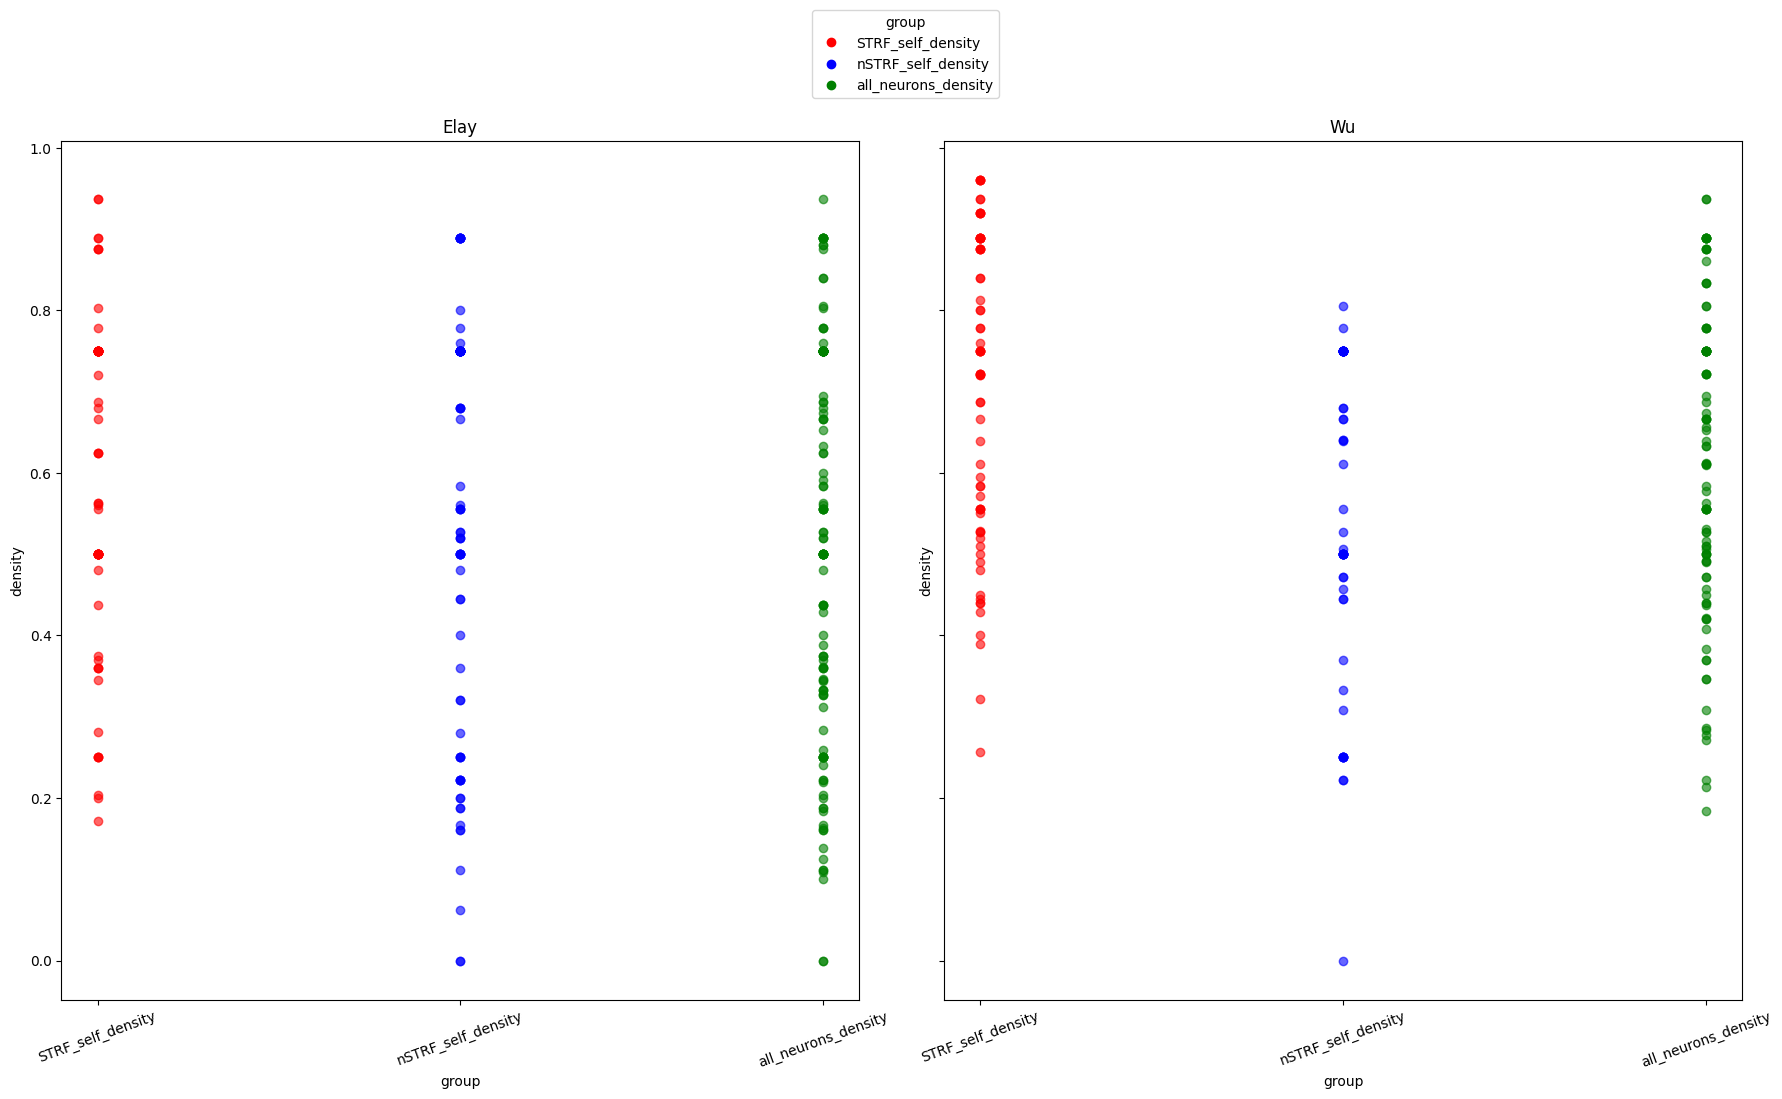

In [47]:

# per monkey / per group stats
stats = density_df.groupby('monkey')[all_groups].agg(['count', 'mean', 'std'])
print(stats)

# Plot each monkey separately with all groups in one scatter plot per monkey
fig, axes = plt.subplots(1, len(monkeys), figsize=(18, 10), sharey=True)
if len(monkeys) == 1:
    axes = [axes]

for ax, (monkey, group_df) in zip(axes, density_df.groupby('monkey')):
    x = np.arange(len(all_groups))
    for i, col in enumerate(all_groups):
        ax.scatter(np.full(len(group_df), x[i]), group_df[col], alpha=0.6, label=col, color=group_colors[col])
    ax.set_title(monkey)
    ax.set_xticks(x)
    ax.set_xticklabels(all_groups, rotation=20)
    ax.set_xlabel('group')
    ax.set_ylabel('density')
    

handles = [plt.Line2D([], [], marker='o', linestyle='', color=group_colors[col], label=col)
           for col in all_groups]
fig.legend(handles=handles, title='group', loc='center left', bbox_to_anchor=(0.45, 1.05))
fig.tight_layout()

## all levels

### scatter

                 STRF_self_density                     nSTRF_self_density  \
                             count      mean       std              count   
monkey condition                                                            
Elay   A-hit                    17  0.658242  0.209470                 21   
       A-miss                   17  0.524595  0.191272                 21   
       AV-hit                   17  0.677304  0.178873                 21   
       AV-miss                  17  0.502951  0.183549                 21   
Wu     A-hit                    19  0.716111  0.183535                 15   
       A-miss                   19  0.703603  0.190450                 15   
       AV-hit                   19  0.777629  0.140811                 15   
       AV-miss                  19  0.647435  0.207451                 15   

                                     all_neurons_density                      
                      mean       std               count      mean       

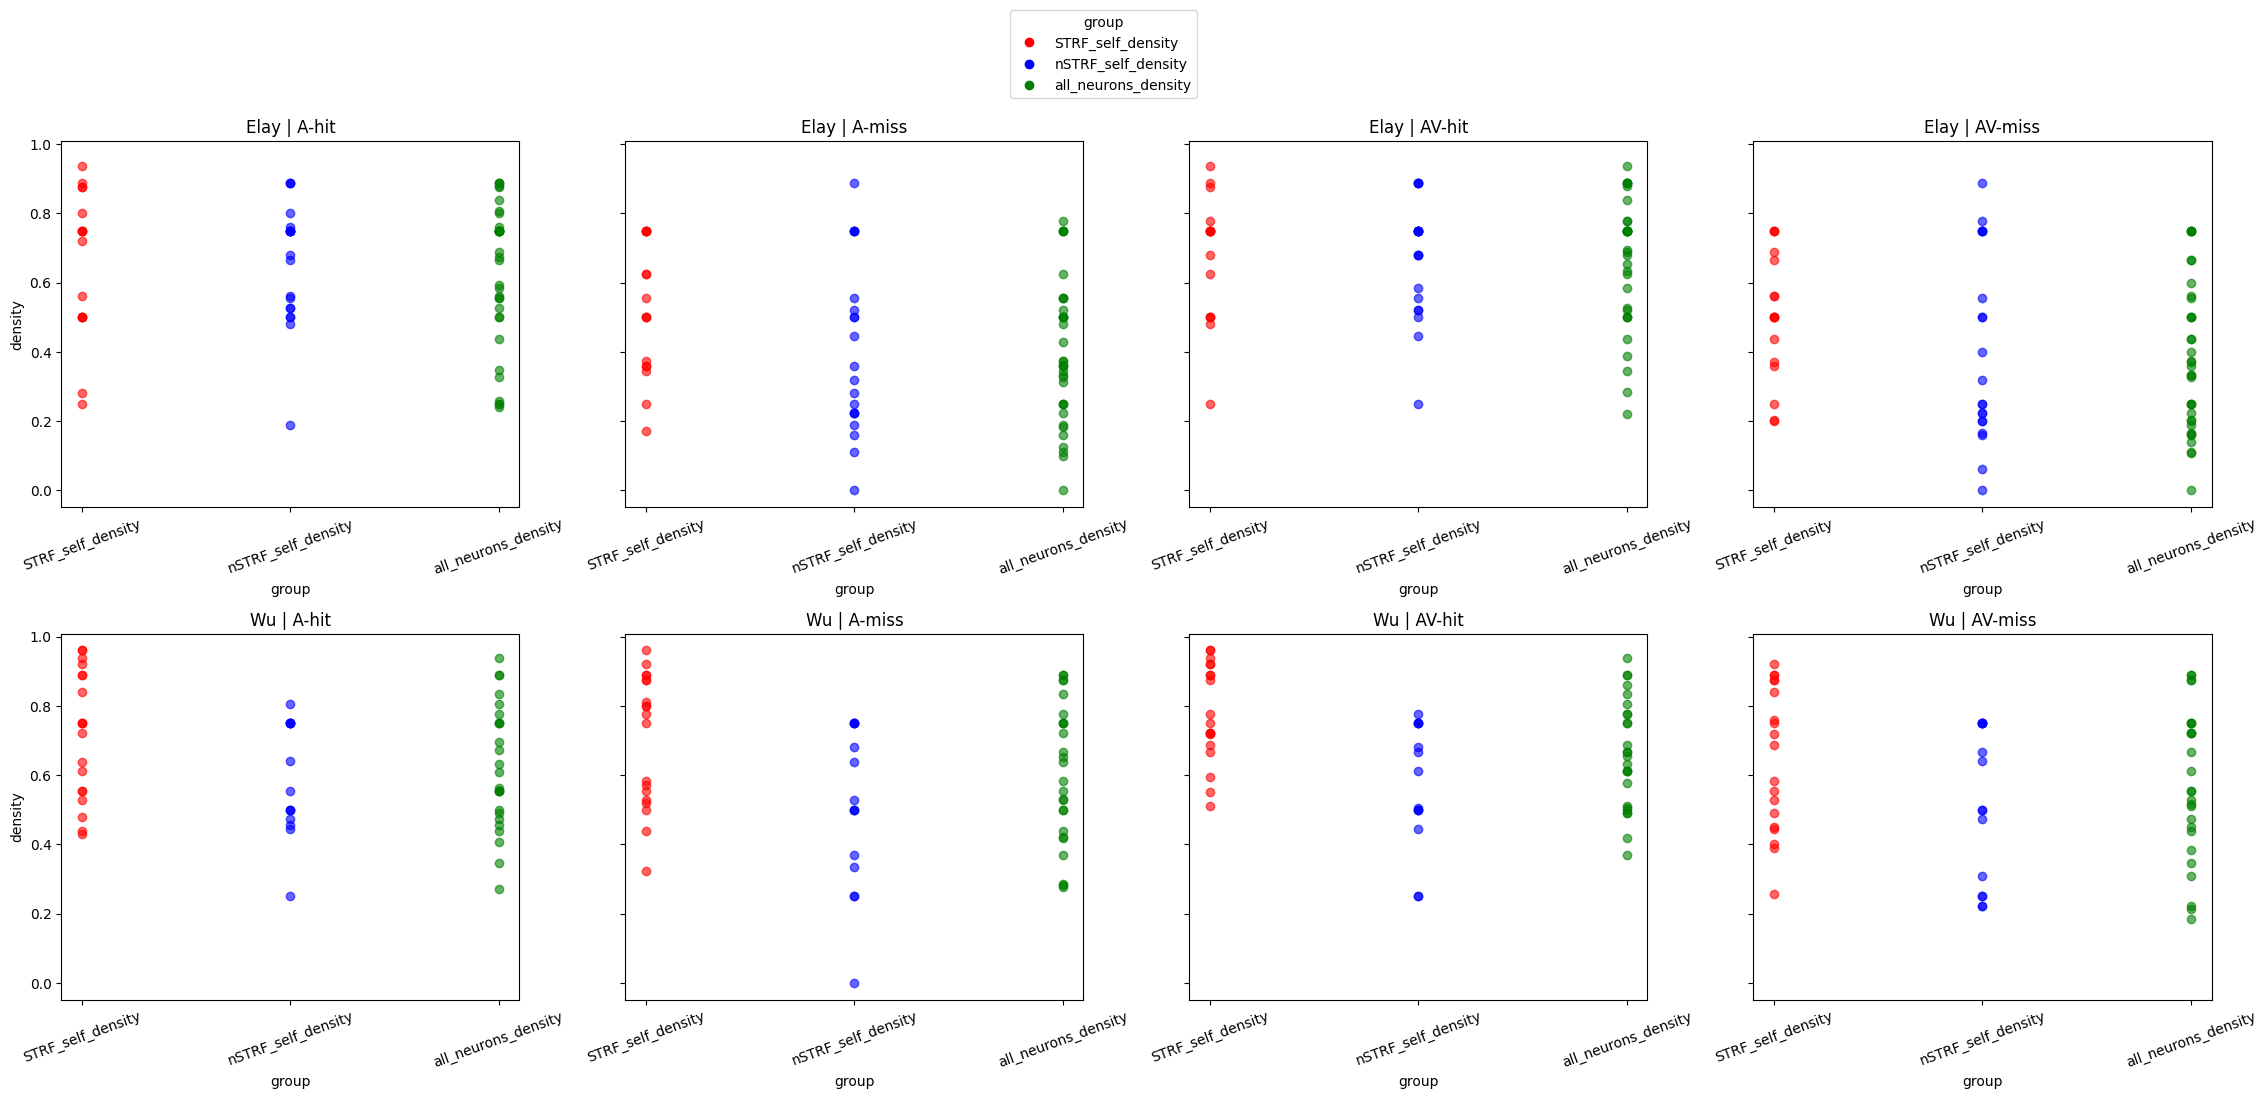

In [48]:
# per monkey / per condition / per group stats
stats_mc = density_df.groupby(['monkey', 'condition'])[all_groups].agg(['count', 'mean', 'std'])
print(stats_mc)

# Plot each monkey/condition separately with all groups in a separate scatter subplot
fig, axes = plt.subplots(len(monkeys), len(all_cond), figsize=(24, 10), sharey=True, squeeze=False)
for i, monkey in enumerate(monkeys):
    for j, cond in enumerate(all_cond):
        ax = axes[i, j]
        subset = density_df[(density_df['monkey'] == monkey) & (density_df['condition'] == cond)]
        x = np.arange(len(all_groups))
        for k, col in enumerate(all_groups):
            ax.scatter(np.full(len(subset), x[k]), subset[col], alpha=0.6, label=col, color=group_colors[col])
        ax.set_title(f"{monkey} | {cond}")
        ax.set_xticks(x)
        ax.set_xticklabels(all_groups, rotation=20)
        ax.set_xlabel('group')
        if j == 0:
            ax.set_ylabel('density')

# Shared legend outside the figure
handles = [plt.Line2D([], [], marker='o', linestyle='', color=group_colors[col], label=col)
           for col in all_groups]
fig.legend(handles=handles, title='group', loc='center left', bbox_to_anchor=(0.42, 1.05))
fig.tight_layout(rect=[0, 0, 0.95, 1])

### t-test

                 STRF_self_density                     nSTRF_self_density  \
                             count      mean       std              count   
monkey condition                                                            
Elay   A-hit                    17  0.658242  0.209470                 21   
       A-miss                   17  0.524595  0.191272                 21   
       AV-hit                   17  0.677304  0.178873                 21   
       AV-miss                  17  0.502951  0.183549                 21   
Wu     A-hit                    19  0.716111  0.183535                 15   
       A-miss                   19  0.703603  0.190450                 15   
       AV-hit                   19  0.777629  0.140811                 15   
       AV-miss                  19  0.647435  0.207451                 15   

                                     all_neurons_density                      
                      mean       std               count      mean       

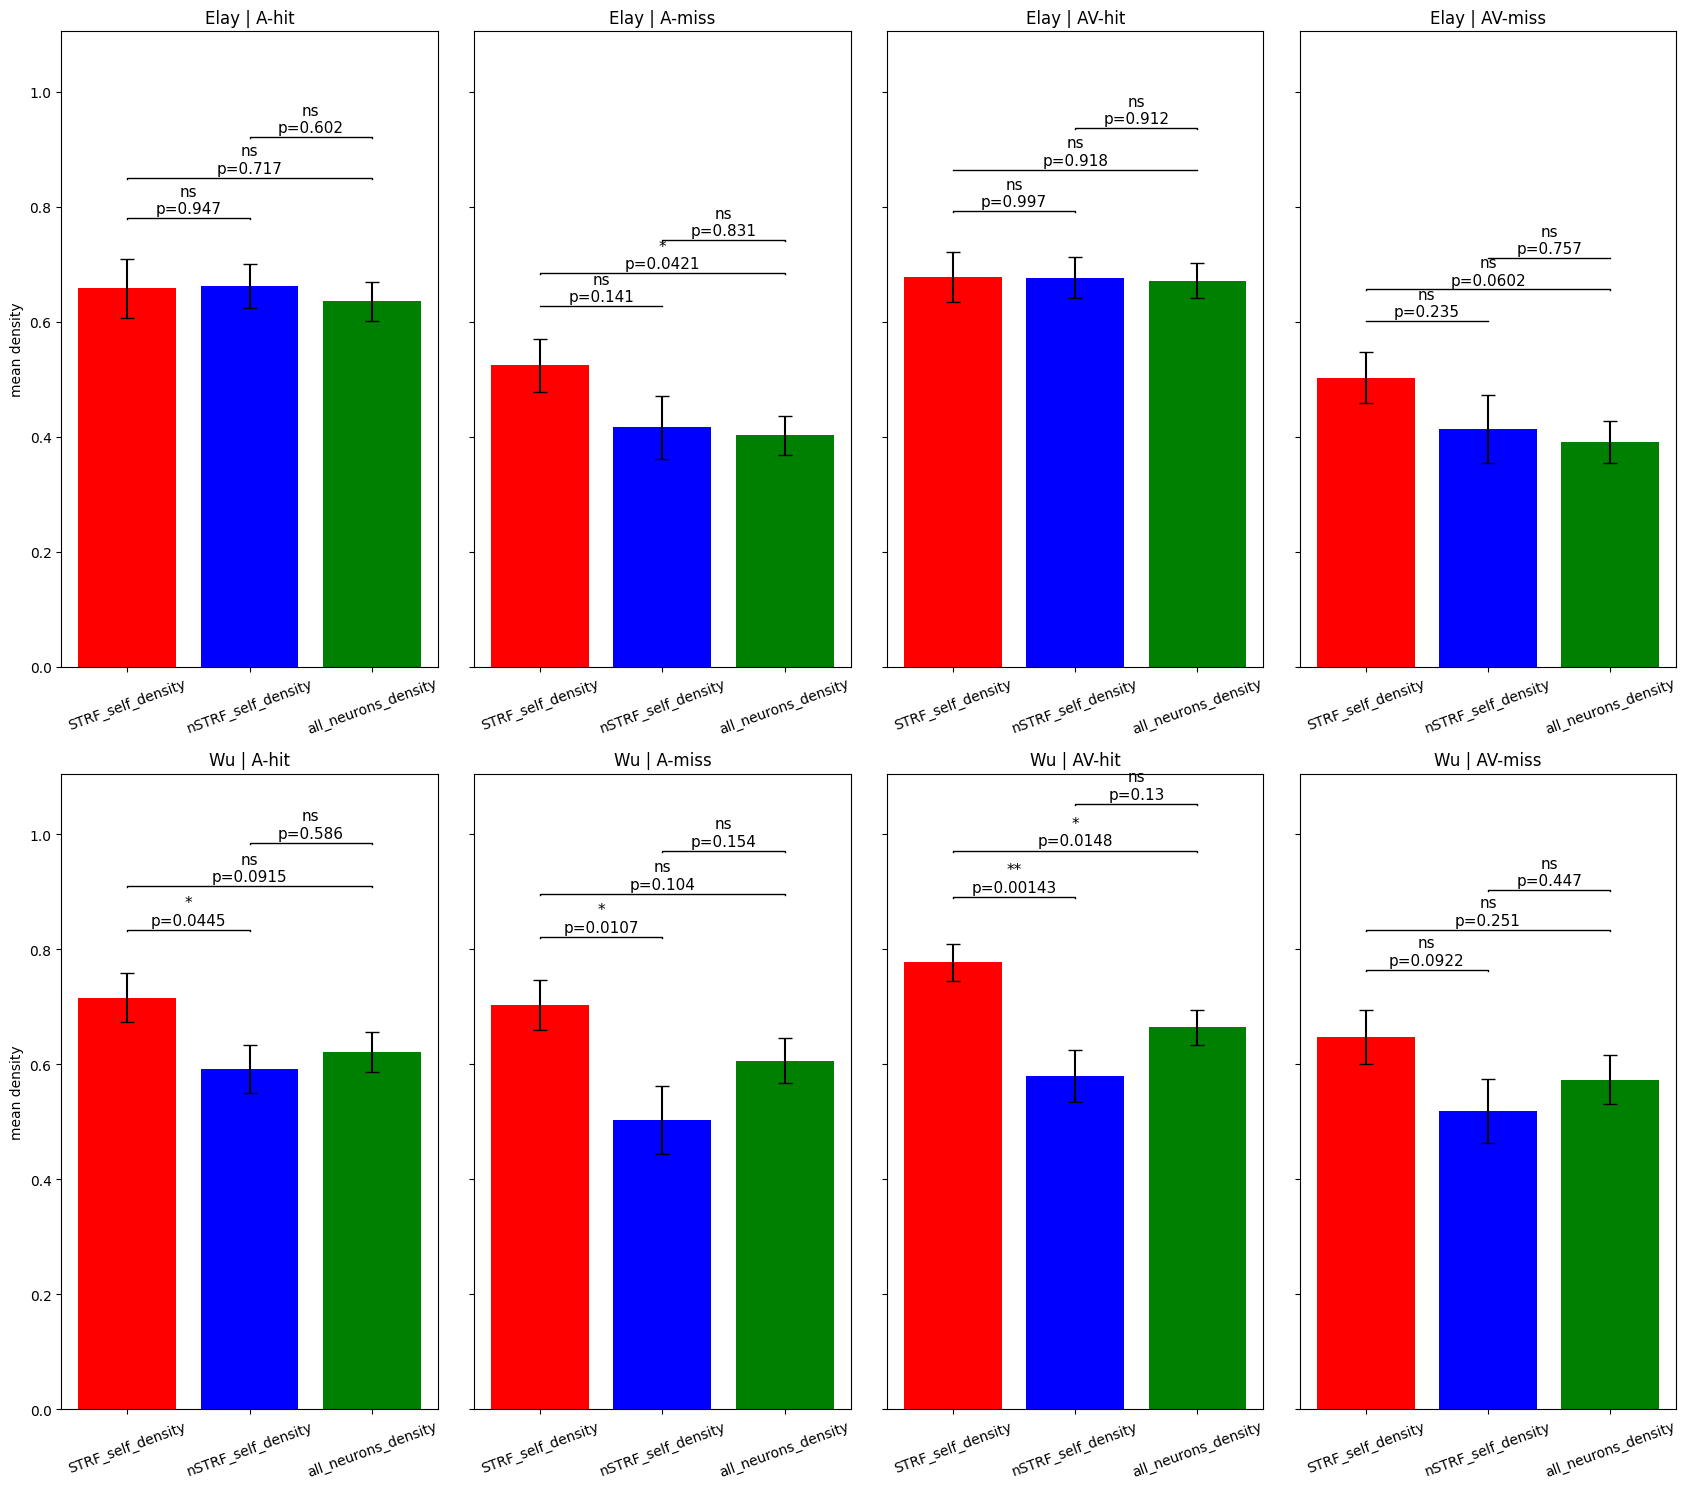

In [73]:
from scipy.stats import ttest_ind

# per monkey / per condition / per group stats with t-tests
stats_mc = density_df.groupby(['monkey', 'condition'])[all_groups].agg(['count', 'mean', 'std'])
print(stats_mc)

fig, axes = plt.subplots(len(monkeys), len(all_cond), figsize=(18, 15), sharey=True, squeeze=False)
pairs = [(0, 1), (0, 2), (1, 2)]
for i, monkey in enumerate(monkeys):
    for j, cond in enumerate(all_cond):
        ax = axes[i, j]
        subset = density_df[(density_df['monkey'] == monkey) & (density_df['condition'] == cond)]
        means = [subset[col].mean() for col in all_groups]
        sems = [subset[col].std(ddof=1) / np.sqrt(subset[col].count()) if subset[col].count() > 0 else np.nan
                for col in all_groups]

        x = np.arange(len(all_groups))
        ax.bar(x, means, yerr=sems, capsize=5, color=[group_colors[col] for col in all_groups])
        ax.set_xticks(x)
        ax.set_xticklabels(all_groups, rotation=20)
        ax.set_title(f"{monkey} | {cond}")
        if j == 0:
            ax.set_ylabel('mean density')

        y_base = np.nanmax(np.array(means) + np.array(sems))
        if np.isnan(y_base):
            y_base = 0.0
        y_step = max(0.1 * y_base, 0.05)

        for k, (a, b) in enumerate(pairs):
            x1, x2 = x[a], x[b]
            data_a = subset[all_groups[a]].dropna()
            data_b = subset[all_groups[b]].dropna()
            if len(data_a) < 2 or len(data_b) < 2:
                pval = np.nan
                tstat = np.nan
                stars = 'n/a'
            else:
                tstat, pval = ttest_ind(data_a, data_b, equal_var=False)
                if pval < 0.001:
                    stars = '***'
                elif pval < 0.01:
                    stars = '**'
                elif pval < 0.05:
                    stars = '*'
                else:
                    stars = 'ns'

            y = y_base + (k + 1) * y_step
            ax.plot([x1, x1, x2, x2], [y - 0.02 * y_step, y, y, y - 0.02 * y_step], color='black', lw=1)
            ax.text((x1 + x2) / 2, y + 0.05 * y_step,
                    f'{stars}\np={pval:.3g}', ha='center', va='bottom', fontsize=11)
            print(f'{monkey} | {cond} | {all_groups[a]} vs {all_groups[b]}: t={tstat:.2f}, p={pval:.3g}, sig={stars}')

fig.tight_layout(rect=[0, 0, 0.95, 1])

# 2. by Neuron Populations

                 STRF_self_density                     nSTRF_self_density  \
                             count      mean       std              count   
monkey condition                                                            
Elay   A-hit                    17  0.658242  0.209470                 21   
       A-miss                   17  0.524595  0.191272                 21   
       AV-hit                   17  0.677304  0.178873                 21   
       AV-miss                  17  0.502951  0.183549                 21   
Wu     A-hit                    19  0.716111  0.183535                 15   
       A-miss                   19  0.703603  0.190450                 15   
       AV-hit                   19  0.777629  0.140811                 15   
       AV-miss                  19  0.647435  0.207451                 15   

                                     all_neurons_density                      
                      mean       std               count      mean       

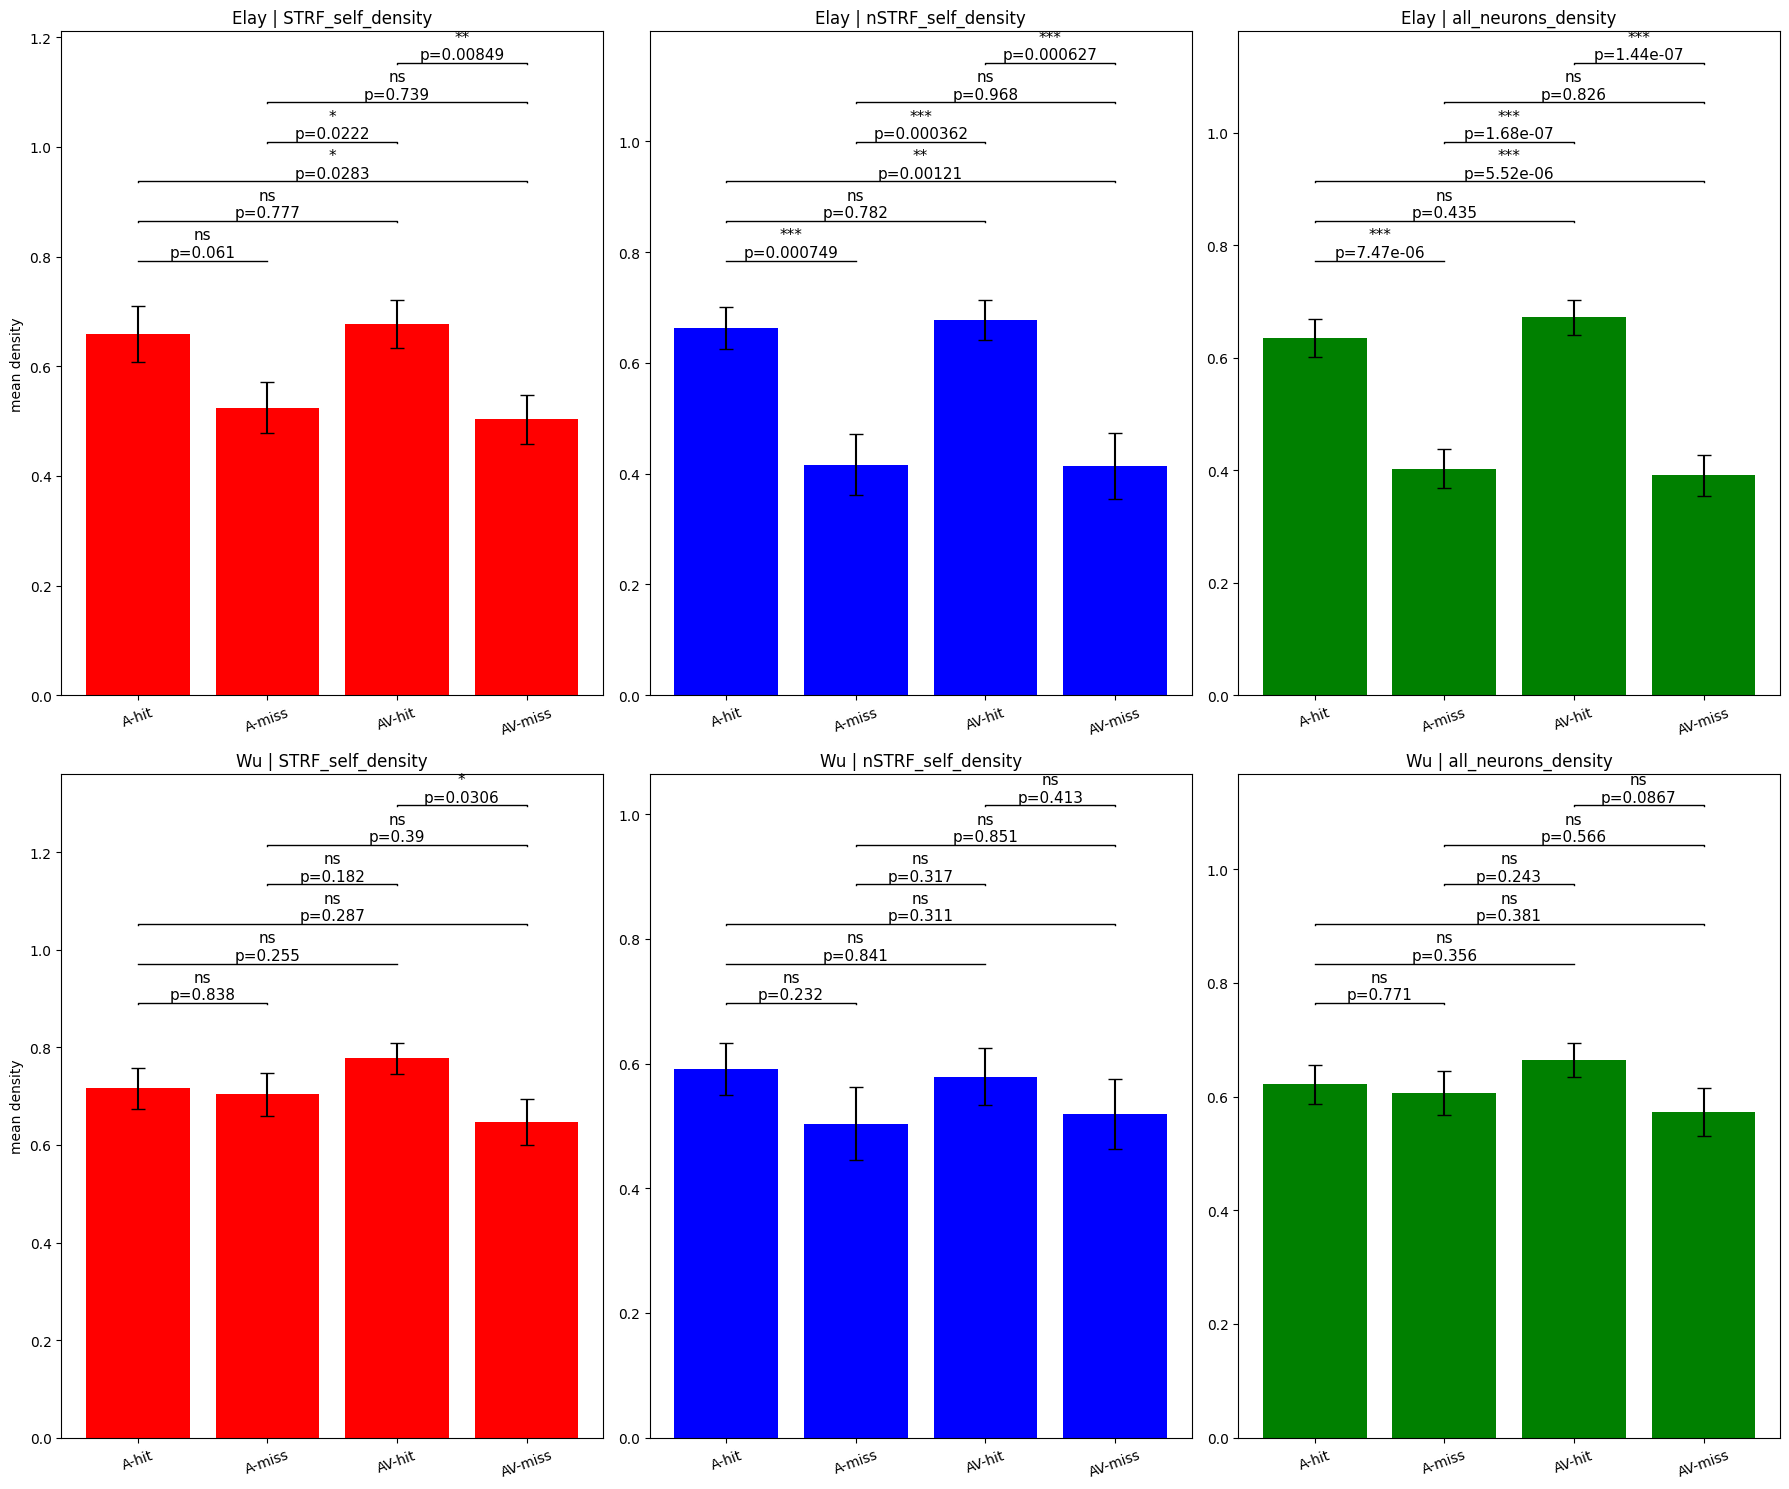

In [70]:
# per monkey / per group / across conditions stats with t-tests
stats_mg = density_df.groupby(['monkey', 'condition'])[all_groups].agg(['count', 'mean', 'std'])
print(stats_mg)

fig, axes = plt.subplots(len(monkeys), len(all_groups), figsize=(18, 15), sharey=False, squeeze=False)
cond_pairs = [(0, 1), (0, 2), (0, 3), (1, 2), (1, 3), (2, 3)]

for i, monkey in enumerate(monkeys):
    for j, group in enumerate(all_groups):
        ax = axes[i, j]
        means = []
        sems = []
        
        for cond in all_cond:
            subset = density_df[(density_df['monkey'] == monkey) & (density_df['condition'] == cond)]
            mean = subset[group].mean()
            sem = subset[group].std(ddof=1) / np.sqrt(subset[group].count()) if subset[group].count() > 0 else np.nan
            means.append(mean)
            sems.append(sem)

        x = np.arange(len(all_cond))
        group_color = group_colors[group]
        ax.bar(x, means, yerr=sems, capsize=5, color=group_color)
        ax.set_xticks(x)
        ax.set_xticklabels(all_cond, rotation=20)
        ax.set_title(f"{monkey} | {group}")
        if j == 0:
            ax.set_ylabel('mean density')

        y_base = np.nanmax(np.array(means) + np.array(sems))
        if np.isnan(y_base):
            y_base = 0.0
        y_step = max(0.1 * y_base, 0.05)

        for k, (a, b) in enumerate(cond_pairs):
            if a >= len(all_cond) or b >= len(all_cond):
                continue
            x1, x2 = x[a], x[b]
            data_a = density_df[(density_df['monkey'] == monkey) & (density_df['condition'] == all_cond[a])][group].dropna()
            data_b = density_df[(density_df['monkey'] == monkey) & (density_df['condition'] == all_cond[b])][group].dropna()
            
            if len(data_a) < 2 or len(data_b) < 2:
                pval = np.nan
                tstat = np.nan
                stars = 'n/a'
            else:
                tstat, pval = ttest_ind(data_a, data_b, equal_var=False)
                if pval < 0.001:
                    stars = '***'
                elif pval < 0.01:
                    stars = '**'
                elif pval < 0.05:
                    stars = '*'
                else:
                    stars = 'ns'

            y = y_base + (k + 1) * y_step
            ax.plot([x1, x1, x2, x2], [y - 0.015 * y_step, y, y, y - 0.02 * y_step], color='black', lw=1)
            ax.text((x1 + x2) / 2, y + 0.02 * y_step,
                    f'{stars}\np={pval:.3g}', ha='center', va='bottom', fontsize=11)
            print(f'{monkey} | {group} | {all_cond[a]} vs {all_cond[b]}: t={tstat:.2f}, p={pval:.3g}, sig={stars}')

fig.tight_layout(rect=[0, 0, 1, 1])

# 3. overtime

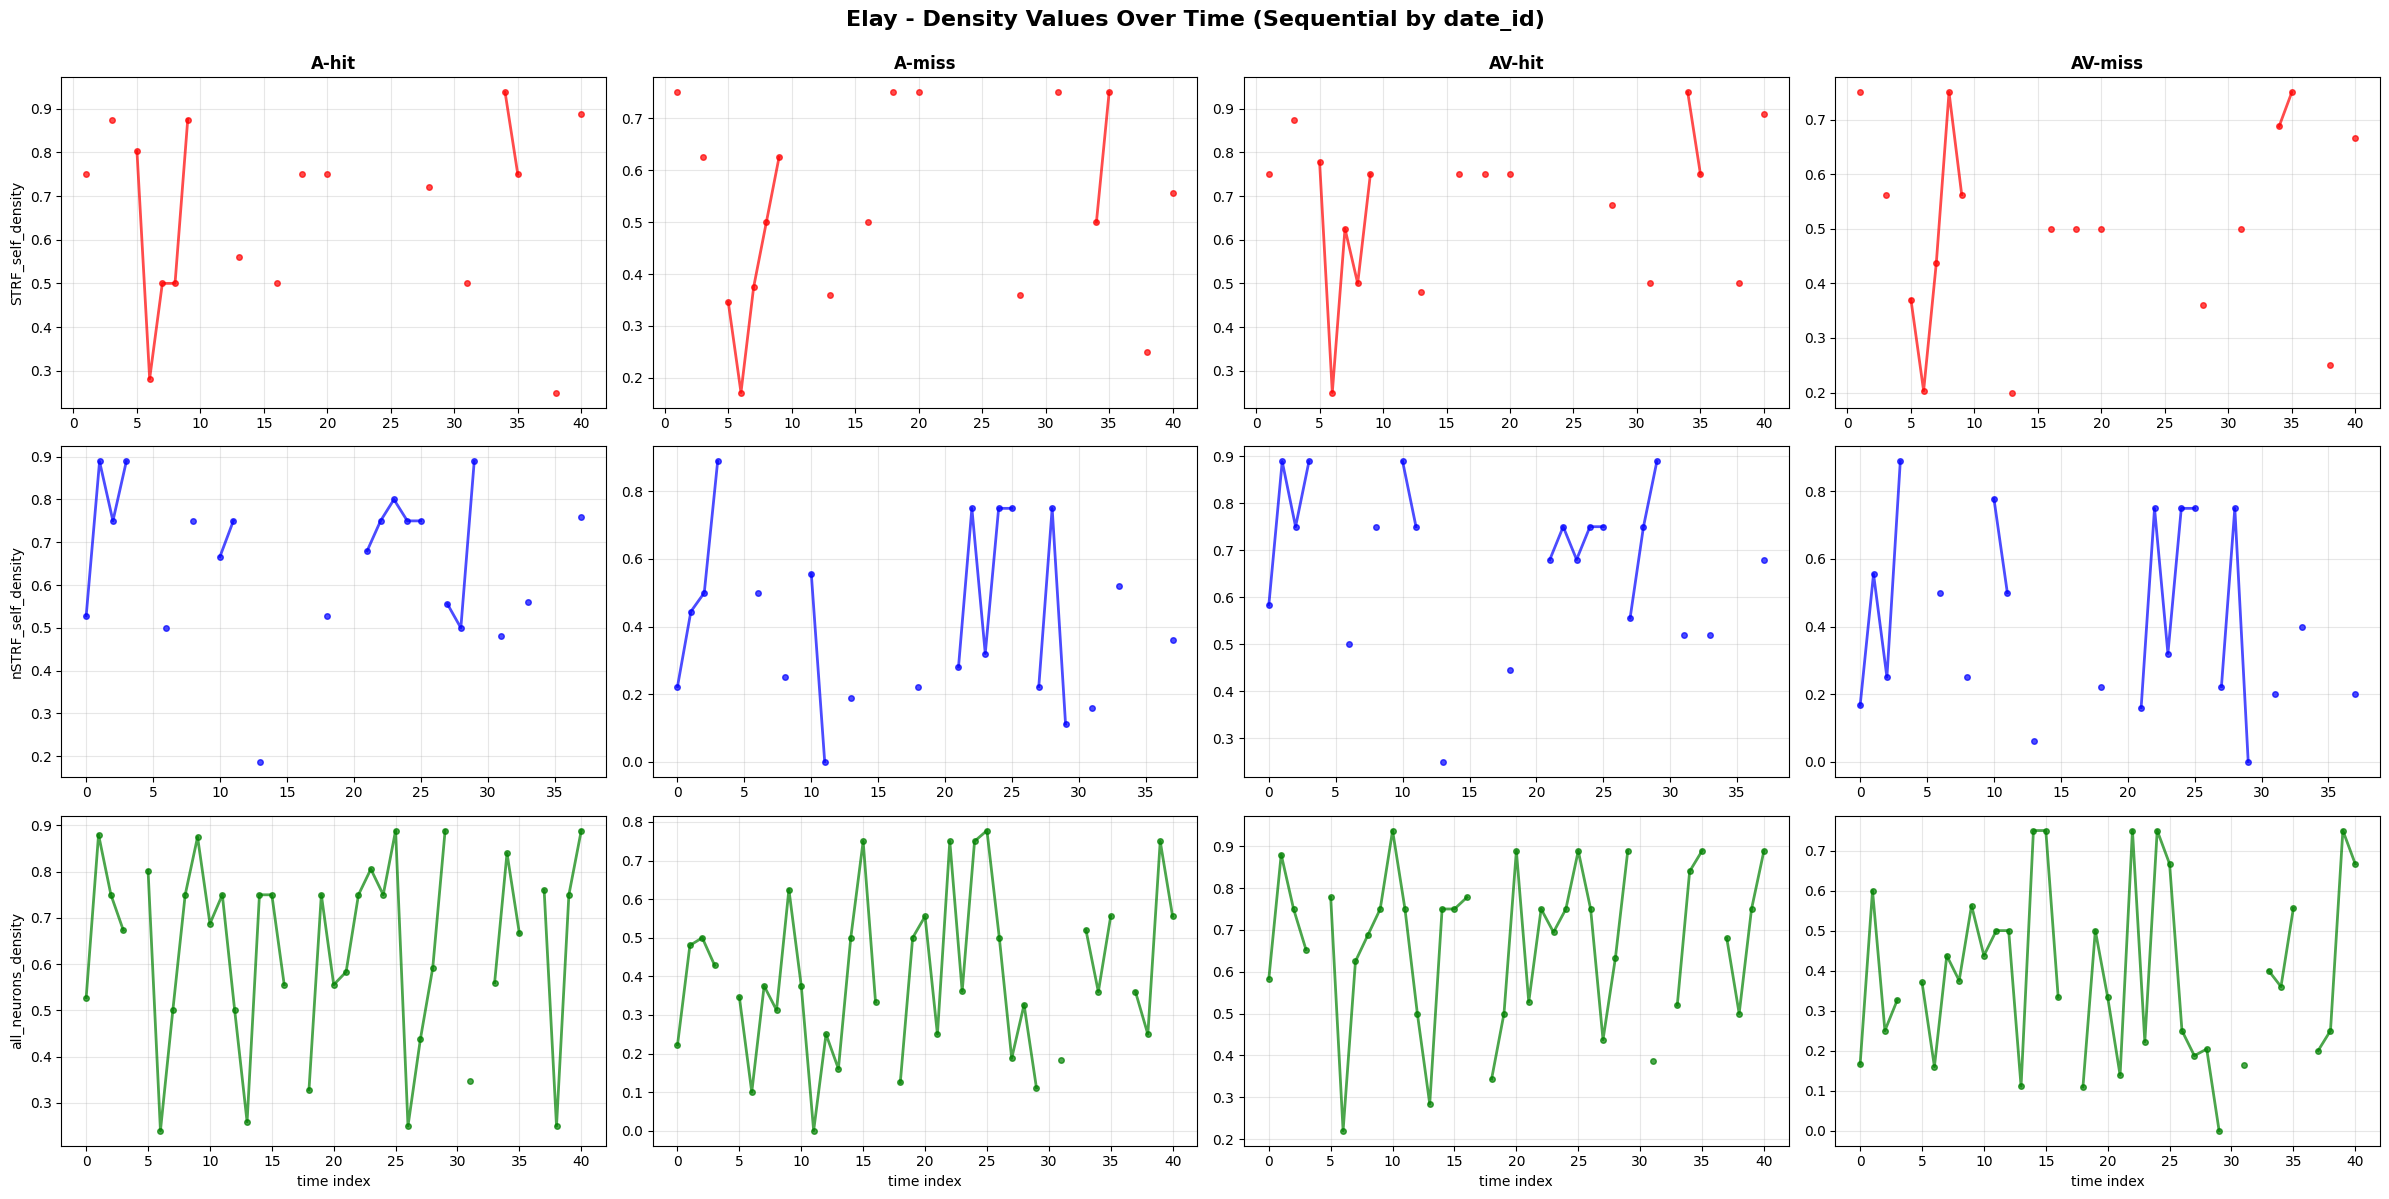

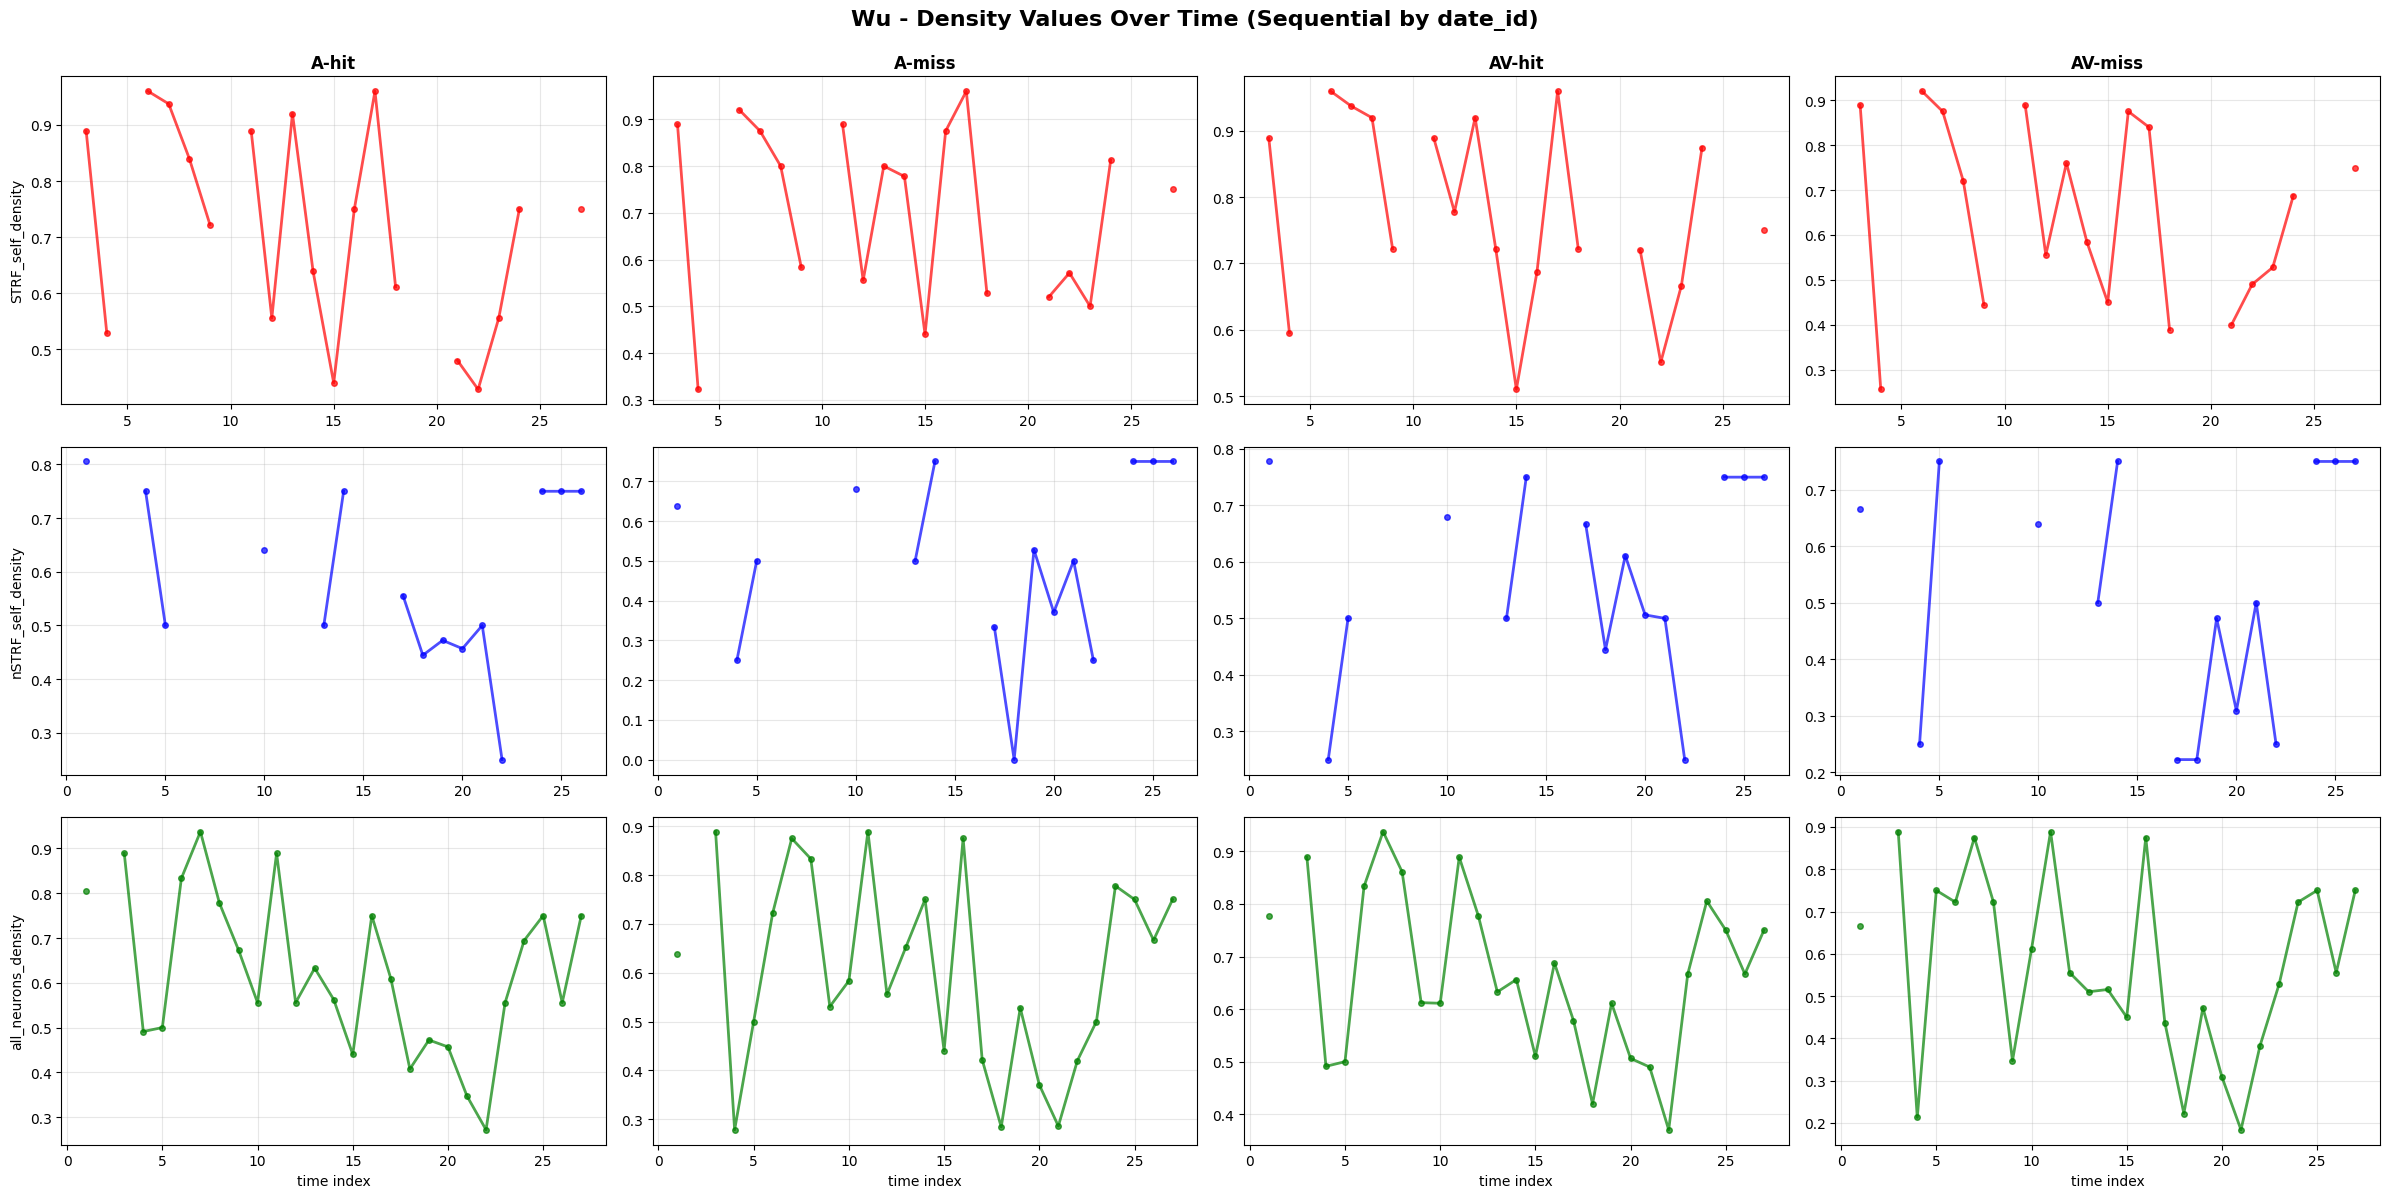

In [60]:
# Plot density values over time (date_id) for each monkey, condition, and group
# Create separate plots for each monkey
for monkey in monkeys:
    fig, axes = plt.subplots(len(all_groups), len(all_cond), figsize=(24, 12), sharey=False, squeeze=False)
    
    for j, group in enumerate(all_groups):
        for k, cond in enumerate(all_cond):
            ax = axes[j, k]
            
            # Filter data for this monkey, condition, and group
            subset = density_df[(density_df['monkey'] == monkey) & (density_df['condition'] == cond)]
            
            # Sort by date_id to ensure chronological order
            subset = subset.sort_values('date_id')
            
            # Create x-axis as sequential indices (treating date_id as IDs, not uniformly spaced dates)
            x = np.arange(len(subset))
            
            # Plot the line for this group
            ax.plot(x, subset[group].values, marker='o', linestyle='-', 
                   label=group, color=group_colors[group], linewidth=2, markersize=4, alpha=0.7)
            
            # Set labels and title
            if j == 0:
                ax.set_title(f"{cond}", fontsize=12, fontweight='bold')
            if k == 0:
                ax.set_ylabel(f"{group}", fontsize=10)
            if j == len(all_groups) - 1:
                ax.set_xlabel('time index', fontsize=10)
            
            ax.grid(True, alpha=0.3)
            
    
    fig.suptitle(f'{monkey} - Density Values Over Time (Sequential by date_id)', fontsize=16, fontweight='bold', y=0.995)
    fig.tight_layout()
    plt.show()

# 4. 